
# Notebook 2 — Standard Transformer Scaling Study

Project: **SVG-GPT: Scaling Transformer Language Models for Vector Graphics**

This notebook completes **Part 2**: standard-parameterization decoder-only Transformer scaling.

It loads the tokenized SVG data from Notebook 1, runs a Tiny-model learning-rate sweep, trains 5 model sizes for exactly 1 epoch each, saves checkpoints/metrics to Google Drive, and produces training curves plus a scaling-law plot.


In [1]:

import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB



## 1. Mounting Google Drive

Notebook 2 reads:

```text
MyDrive/svg_gpt_scaling/notebook1_preprocessing/
```

and writes:

```text
MyDrive/svg_gpt_scaling/notebook2_standard_scaling/
  checkpoints/
  logs/
  results/
  plots/
```


In [2]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/svg_gpt_scaling')
NOTEBOOK1_DIR = PROJECT_ROOT / 'notebook1_preprocessing'
NOTEBOOK2_DIR = PROJECT_ROOT / 'notebook2_standard_scaling'
CHECKPOINTS_DIR = NOTEBOOK2_DIR / 'checkpoints'
LOGS_DIR = NOTEBOOK2_DIR / 'logs'
RESULTS_DIR = NOTEBOOK2_DIR / 'results'
PLOTS_DIR = NOTEBOOK2_DIR / 'plots'
for d in [CHECKPOINTS_DIR, LOGS_DIR, RESULTS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('Notebook 1 folder:', NOTEBOOK1_DIR)
print('Notebook 2 folder:', NOTEBOOK2_DIR)


Notebook 1 folder: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing
Notebook 2 folder: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling



## 2. Installing Dependencies


In [4]:

!pip -q install tokenizers pandas matplotlib scipy tqdm numpy


In [5]:

import os, json, math, time, random, gc
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.nn import functional as F
from tokenizers import Tokenizer

print('Imports complete.')


Imports complete.



## 3. Configuring the Notebook

`SANITY_MODE = True` first. After the sanity run works, I will switch it to `False` for the real Part 2 run.


In [6]:

SANITY_MODE = False  # first run True for debugging; final run False
RANDOM_SEED = 42

VOCAB_SIZE = 4096
BLOCK_SIZE = 512
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'

MICRO_BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 4
TOKENS_PER_STEP = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS * BLOCK_SIZE

EVAL_INTERVAL = 500
EVAL_ITERS = 100
LOG_INTERVAL = 50
SANITY_MAX_STEPS = 30
SANITY_EVAL_ITERS = 10

LR_SWEEP_VALUES = [1e-4, 2e-4, 3e-4, 6e-4, 1e-3, 2e-3, 3e-3]
LR_SWEEP_MAX_STEPS_REAL = 1000

WARMUP_FRACTION = 0.03
MIN_LR_RATIO = 0.10
WEIGHT_DECAY = 0.1
BETA1, BETA2 = 0.9, 0.95
GRAD_CLIP = 1.0
RESUME_IF_EXISTS = True

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)

print('SANITY_MODE:', SANITY_MODE)
print('DEVICE:', DEVICE, '| DTYPE:', DTYPE)
print('TOKENS_PER_STEP:', TOKENS_PER_STEP)


SANITY_MODE: False
DEVICE: cuda | DTYPE: bfloat16
TOKENS_PER_STEP: 32768



## 4. Loading Notebook 1 Tokenized Data


In [7]:

preprocess_config_path = NOTEBOOK1_DIR / 'preprocess_config_full.json'
if not preprocess_config_path.exists():
    raise FileNotFoundError(f'Missing {preprocess_config_path}. Finish Notebook 1 in full mode first.')
with open(preprocess_config_path, 'r', encoding='utf-8') as f:
    preprocess_config = json.load(f)

tokenizer_path = Path(preprocess_config['tokenizer_path'])
train_bin_path = Path(preprocess_config['token_files']['train']['bin_path'])
val_bin_path = Path(preprocess_config['token_files']['val']['bin_path'])
test_bin_path = Path(preprocess_config['token_files']['test']['bin_path'])
for p in [tokenizer_path, train_bin_path, val_bin_path, test_bin_path]:
    if not p.exists(): raise FileNotFoundError(p)

tokenizer = Tokenizer.from_file(str(tokenizer_path))
train_tokens = np.memmap(train_bin_path, dtype=np.uint16, mode='r')
val_tokens = np.memmap(val_bin_path, dtype=np.uint16, mode='r')
test_tokens = np.memmap(test_bin_path, dtype=np.uint16, mode='r')

print('Tokenizer vocab size:', tokenizer.get_vocab_size())
print(f'Train tokens: {len(train_tokens):,}')
print(f'Val tokens:   {len(val_tokens):,}')
print(f'Test tokens:  {len(test_tokens):,}')
print('Steps per real epoch:', len(train_tokens) // TOKENS_PER_STEP)


Tokenizer vocab size: 4096
Train tokens: 164,389,332
Val tokens:   1,657,304
Test tokens:  1,655,554
Steps per real epoch: 5016



## 5. Building the Batch Loader


In [8]:

def get_batch(split: str, batch_size: int = MICRO_BATCH_SIZE, block_size: int = BLOCK_SIZE):
    data = train_tokens if split == 'train' else val_tokens if split == 'val' else test_tokens
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(np.array(data[i:i+block_size], dtype=np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(np.array(data[i+1:i+1+block_size], dtype=np.int64)) for i in ix])
    if DEVICE == 'cuda':
        x = x.pin_memory().to(DEVICE, non_blocking=True)
        y = y.pin_memory().to(DEVICE, non_blocking=True)
    else:
        x, y = x.to(DEVICE), y.to(DEVICE)
    return x, y

xb, yb = get_batch('train')
print(xb.shape, yb.shape, xb.dtype, xb.min().item(), xb.max().item())


torch.Size([16, 512]) torch.Size([16, 512]) torch.int64 1 3846



## 6. Defining the GPT-Style Decoder-Only Transformer

This is a compact nanoGPT-style decoder-only model: token embeddings, positional embeddings, causal self-attention, MLP blocks, residual connections, layer normalization, and tied input/output embeddings.


In [9]:

@dataclass
class GPTConfig:
    name: str
    vocab_size: int
    block_size: int
    n_layer: int
    n_head: int
    n_embd: int
    d_ff: int
    dropout: float = 0.0
    bias: bool = True

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer('mask', torch.tril(torch.ones(config.block_size, config.block_size)).view(1,1,config.block_size,config.block_size))
    def forward(self, x):
        B,T,C = x.size()
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        if self.flash:
            y = F.scaled_dot_product_attention(q,k,v, attn_mask=None, dropout_p=self.dropout if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2,-1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.resid_dropout(self.c_proj(y))

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, config.d_ff, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(config.d_ff, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=nn.LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None: nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
    def forward(self, idx, targets=None):
        B,T = idx.shape
        assert T <= self.config.block_size
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h: x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss
    def configure_optimizers(self, weight_decay, learning_rate, betas):
        params = {n:p for n,p in self.named_parameters() if p.requires_grad}
        decay = [p for n,p in params.items() if p.dim() >= 2]
        nodecay = [p for n,p in params.items() if p.dim() < 2]
        groups = [{'params': decay, 'weight_decay': weight_decay}, {'params': nodecay, 'weight_decay': 0.0}]
        fused_available = 'fused' in torch.optim.AdamW.__init__.__code__.co_varnames
        kwargs = dict(lr=learning_rate, betas=betas)
        if fused_available and DEVICE == 'cuda': kwargs['fused'] = True
        return torch.optim.AdamW(groups, **kwargs)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print('Model defined.')


Model defined.



## 7. Defining Model Sizes

The project asks for at least 5 model sizes. These are based on the suggested configurations, adjusted for the 4096-token SVG vocabulary.


In [10]:

MODEL_CONFIGS = [
    GPTConfig('Tiny', VOCAB_SIZE, BLOCK_SIZE, 4, 4, 128, 512, 0.0),
    GPTConfig('Small', VOCAB_SIZE, BLOCK_SIZE, 6, 6, 192, 768, 0.0),
    GPTConfig('Medium', VOCAB_SIZE, BLOCK_SIZE, 6, 6, 384, 1536, 0.0),
    GPTConfig('Large', VOCAB_SIZE, BLOCK_SIZE, 10, 8, 512, 2048, 0.0),
    GPTConfig('XL', VOCAB_SIZE, BLOCK_SIZE, 12, 12, 768, 3072, 0.0),
]
rows=[]
for cfg in MODEL_CONFIGS:
    m=GPT(cfg); params=count_parameters(m); del m; gc.collect()
    rows.append({**asdict(cfg), 'params': params, 'params_millions': params/1e6})
df_arch = pd.DataFrame(rows)
display(df_arch[['name','params','params_millions','n_embd','n_layer','n_head','d_ff','block_size']])
df_arch.to_csv(RESULTS_DIR/'standard_model_architectures.csv', index=False)


,name,params,params_millions,n_embd,n_layer,n_head,d_ff,block_size
0,Tiny,1383168,1.383168,128,4,4,512,512
1,Small,3554304,3.554304,192,6,6,768,512
2,Medium,12417024,12.417024,384,6,6,1536,512
3,Large,33884160,33.884160,512,10,8,2048,512
4,XL,88594944,88.594944,768,12,12,3072,512



## 8. Preparing Training Utilities


In [11]:

def get_lr(iter_num, max_lr, max_iters, warmup_iters):
    min_lr = max_lr * MIN_LR_RATIO
    if iter_num < warmup_iters:
        return max_lr * (iter_num + 1) / max(1, warmup_iters)
    if iter_num > max_iters:
        return min_lr
    decay_ratio = (iter_num - warmup_iters) / max(1, max_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def gpu_mem_gb():
    return torch.cuda.max_memory_allocated()/(1024**3) if torch.cuda.is_available() else 0.0

@torch.no_grad()
def estimate_loss(model, eval_iters):
    model.eval(); out={}
    for split in ['train','val']:
        losses=[]
        for _ in range(eval_iters):
            X,Y=get_batch(split)
            with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16 if DTYPE=='bfloat16' else torch.float16, enabled=(DEVICE=='cuda')):
                _, loss = model(X,Y)
            losses.append(loss.item())
        out[split]=float(np.mean(losses))
    model.train(); return out

def save_checkpoint(path, model, optimizer, config, metadata):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model_state_dict':model.state_dict(), 'optimizer_state_dict':optimizer.state_dict(), 'config':asdict(config), 'metadata':metadata}, path)

def load_checkpoint(path, model, optimizer=None):
    ckpt=torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer is not None and ckpt.get('optimizer_state_dict') is not None:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    return ckpt

def train_one_run(config, learning_rate, run_name, max_steps=None, eval_interval=EVAL_INTERVAL, eval_iters=EVAL_ITERS, resume=RESUME_IF_EXISTS):
    clear_memory()
    steps_per_epoch = len(train_tokens) // TOKENS_PER_STEP
    if max_steps is None:
        max_steps = SANITY_MAX_STEPS if SANITY_MODE else int(steps_per_epoch)
    warmup_iters = max(1, int(WARMUP_FRACTION * max_steps))
    run_dir = CHECKPOINTS_DIR / run_name
    latest_ckpt = run_dir / 'latest.pt'
    final_ckpt = run_dir / 'final.pt'
    log_path = LOGS_DIR / f'{run_name}.csv'
    summary_path = RESULTS_DIR / f'{run_name}_summary.json'

    print('\n' + '='*80)
    print('Run:', run_name, '| model:', config.name, '| lr:', learning_rate, '| max_steps:', max_steps)
    print('steps_per_epoch:', steps_per_epoch, '| tokens_per_step:', TOKENS_PER_STEP)
    print('='*80)

    model = GPT(config).to(DEVICE)
    optimizer = model.configure_optimizers(WEIGHT_DECAY, learning_rate, (BETA1, BETA2))
    params = count_parameters(model)
    start_iter=0; best_val=float('inf'); logs=[]
    if resume and latest_ckpt.exists():
        print('Resuming:', latest_ckpt)
        ckpt=load_checkpoint(latest_ckpt, model, optimizer)
        meta=ckpt.get('metadata', {})
        start_iter=int(meta.get('iter', -1))+1
        best_val=float(meta.get('best_val_loss', best_val))
        if log_path.exists(): logs=pd.read_csv(log_path).to_dict('records')

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda' and DTYPE=='float16'))
    start_time=time.time(); model.train()
    for it in range(start_iter, max_steps):
        lr=get_lr(it, learning_rate, max_steps, warmup_iters)
        for g in optimizer.param_groups: g['lr']=lr
        optimizer.zero_grad(set_to_none=True)
        accum_loss=0.0
        for _ in range(GRAD_ACCUM_STEPS):
            X,Y=get_batch('train')
            with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16 if DTYPE=='bfloat16' else torch.float16, enabled=(DEVICE=='cuda')):
                _, loss = model(X,Y)
                loss = loss / GRAD_ACCUM_STEPS
            accum_loss += loss.item()
            if scaler.is_enabled(): scaler.scale(loss).backward()
            else: loss.backward()
        if GRAD_CLIP is not None:
            if scaler.is_enabled(): scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        if scaler.is_enabled():
            scaler.step(optimizer); scaler.update()
        else:
            optimizer.step()
        elapsed=time.time()-start_time
        tokens_seen=(it+1)*TOKENS_PER_STEP
        tok_s=tokens_seen/max(elapsed,1e-9)
        if it % LOG_INTERVAL == 0 or it == max_steps-1:
            print(f'iter {it:6d}/{max_steps} | loss {accum_loss:.4f} | lr {lr:.2e} | tok/s {tok_s:,.0f}')
        if (it % eval_interval == 0) or (it == max_steps-1):
            ev=estimate_loss(model, eval_iters)
            best_val=min(best_val, ev['val'])
            row={'run_name':run_name,'model_name':config.name,'iter':it,'max_steps':max_steps,'base_learning_rate':learning_rate,'learning_rate':lr,'train_loss_microbatch':accum_loss,'train_loss_eval':ev['train'],'val_loss':ev['val'],'best_val_loss':best_val,'params':params,'tokens_seen':tokens_seen,'tokens_per_sec':tok_s,'elapsed_sec':elapsed,'gpu_memory_gb':gpu_mem_gb(),'tokens_per_step':TOKENS_PER_STEP,'block_size':BLOCK_SIZE,'micro_batch_size':MICRO_BATCH_SIZE,'grad_accum_steps':GRAD_ACCUM_STEPS}
            logs.append(row); pd.DataFrame(logs).to_csv(log_path, index=False)
            print(f"  eval | train {ev['train']:.4f} | val {ev['val']:.4f} | best {best_val:.4f} | gpu {row['gpu_memory_gb']:.2f} GB")
            save_checkpoint(latest_ckpt, model, optimizer, config, {**row, 'config':asdict(config)})
    total_elapsed=time.time()-start_time
    final_ev=estimate_loss(model, eval_iters)
    metadata={'run_name':run_name,'model_name':config.name,'max_steps':max_steps,'base_learning_rate':learning_rate,'final_train_loss':final_ev['train'],'final_val_loss':final_ev['val'],'best_val_loss':best_val,'params':params,'total_elapsed_sec':total_elapsed,'tokens_seen':max_steps*TOKENS_PER_STEP,'tokens_per_sec':(max_steps*TOKENS_PER_STEP)/max(total_elapsed,1e-9),'gpu_memory_gb':gpu_mem_gb(),'steps_per_epoch':steps_per_epoch,'tokens_per_step':TOKENS_PER_STEP,'block_size':BLOCK_SIZE,'micro_batch_size':MICRO_BATCH_SIZE,'grad_accum_steps':GRAD_ACCUM_STEPS,'config':asdict(config)}
    save_checkpoint(final_ckpt, model, optimizer, config, metadata)
    with open(summary_path,'w') as f: json.dump(metadata,f,indent=2)
    print('Finished:', run_name)
    print('Saved final checkpoint:', final_ckpt)
    print('Saved summary:', summary_path)
    del model, optimizer; clear_memory()
    return metadata

print('Training utilities ready.')


Training utilities ready.



## 9. Sweeping Tiny Model Learning Rates

The sweep uses the Tiny model and selects the LR with the lowest final validation loss.


In [12]:

def run_lr_sweep_tiny():
    mode = 'sanity' if SANITY_MODE else 'real'
    sweep_steps = SANITY_MAX_STEPS if SANITY_MODE else LR_SWEEP_MAX_STEPS_REAL
    eval_iters = SANITY_EVAL_ITERS if SANITY_MODE else EVAL_ITERS
    eval_interval = 10 if SANITY_MODE else max(100, sweep_steps//5)
    results=[]
    for lr in LR_SWEEP_VALUES:
        run_name = f'lr_sweep_tiny_standard_{mode}_lr_{lr:.0e}'.replace('+','')
        summary_path = RESULTS_DIR / f'{run_name}_summary.json'
        if RESUME_IF_EXISTS and summary_path.exists():
            print('Reusing:', summary_path)
            with open(summary_path) as f: meta=json.load(f)
        else:
            meta=train_one_run(MODEL_CONFIGS[0], lr, run_name, max_steps=sweep_steps, eval_interval=eval_interval, eval_iters=eval_iters, resume=RESUME_IF_EXISTS)
        results.append(meta)
    df=pd.DataFrame(results)
    out=RESULTS_DIR / f'lr_sweep_tiny_standard_{mode}.csv'
    df.to_csv(out,index=False)
    best=df.sort_values('final_val_loss').iloc[0]
    best_lr=float(best['base_learning_rate'])
    with open(RESULTS_DIR / f'best_lr_standard_{mode}.json','w') as f:
        json.dump({'best_lr':best_lr,'selection_metric':'final_val_loss','best_run_name':best['run_name'],'mode':mode}, f, indent=2)
    display(df[['run_name','base_learning_rate','final_train_loss','final_val_loss','best_val_loss','params','total_elapsed_sec','tokens_per_sec','gpu_memory_gb']])
    print('Best LR:', best_lr)
    return df, best_lr

df_lr_sweep, BEST_LR = run_lr_sweep_tiny()



Run: lr_sweep_tiny_standard_real_lr_1e-04 | model: Tiny | lr: 0.0001 | max_steps: 1000
steps_per_epoch: 5016 | tokens_per_step: 32768


/tmp/ipykernel_1650/122126338.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda' and DTYPE=='float16'))


iter      0/1000 | loss 8.3414 | lr 3.33e-06 | tok/s 68,270
  eval | train 8.3353 | val 8.3364 | best 8.3364 | gpu 0.55 GB
iter     50/1000 | loss 6.9919 | lr 9.99e-05 | tok/s 236,312
iter    100/1000 | loss 5.9550 | lr 9.88e-05 | tok/s 295,255
iter    150/1000 | loss 5.0539 | lr 9.66e-05 | tok/s 369,361
iter    200/1000 | loss 4.3746 | lr 9.33e-05 | tok/s 422,233
  eval | train 4.3732 | val 4.4155 | best 4.4155 | gpu 0.56 GB
iter    250/1000 | loss 3.9769 | lr 8.91e-05 | tok/s 440,282
iter    300/1000 | loss 3.4073 | lr 8.39e-05 | tok/s 474,563
iter    350/1000 | loss 3.1909 | lr 7.79e-05 | tok/s 502,199
iter    400/1000 | loss 2.9476 | lr 7.14e-05 | tok/s 525,146
  eval | train 2.9716 | val 2.9936 | best 2.9936 | gpu 0.56 GB
iter    450/1000 | loss 2.9152 | lr 6.44e-05 | tok/s 523,390
iter    500/1000 | loss 2.6914 | lr 5.72e-05 | tok/s 540,010
iter    550/1000 | loss 2.6375 | lr 4.99e-05 | tok/s 555,954
iter    600/1000 | loss 2.4759 | lr 4.28e-05 | tok/s 565,048
  eval | train 2.55

,run_name,base_learning_rate,final_train_loss,final_val_loss,best_val_loss,params,total_elapsed_sec,tokens_per_sec,gpu_memory_gb
0,lr_sweep_tiny_standard_real_lr_1e-04,0.0001,2.357761,2.374451,2.376828,1383168,54.303163,603427.096298,0.562698
1,lr_sweep_tiny_standard_real_lr_2e-04,0.0002,1.907250,1.957683,1.954166,1383168,46.426850,705798.471680,0.562698
2,lr_sweep_tiny_standard_real_lr_3e-04,0.0003,1.728083,1.777026,1.761386,1383168,46.376407,706566.169161,0.562698
3,lr_sweep_tiny_standard_real_lr_6e-04,0.0006,1.558880,1.556778,1.546430,1383168,47.276352,693116.085806,0.562698
4,lr_sweep_tiny_standard_real_lr_1e-03,0.0010,1.416811,1.429222,1.450421,1383168,47.068091,696182.902865,0.562698
5,lr_sweep_tiny_standard_real_lr_2e-03,0.0020,1.337545,1.349740,1.348481,1383168,47.967709,683126.231476,0.562698
6,lr_sweep_tiny_standard_real_lr_3e-03,0.0030,1.281612,1.311256,1.286224,1383168,47.805189,685448.604177,0.562698


Best LR: 0.003



## 10. Plotting the LR Sweep


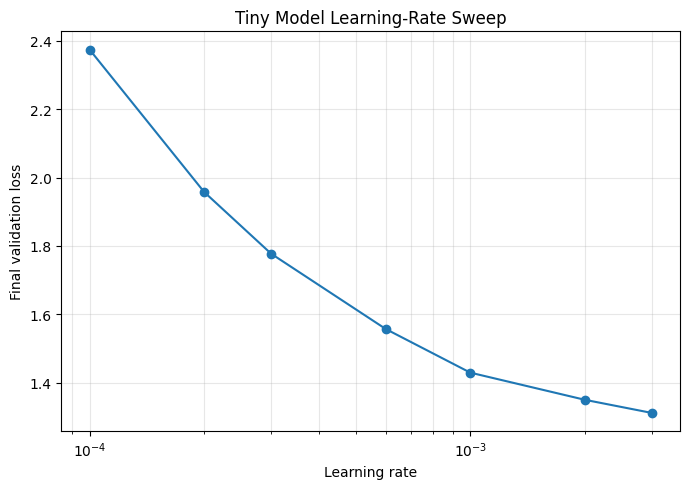

Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/plots/lr_sweep_tiny_standard_real.png
Best LR: 0.003


In [13]:

mode = 'sanity' if SANITY_MODE else 'real'
plt.figure(figsize=(7,5))
plt.plot(df_lr_sweep['base_learning_rate'], df_lr_sweep['final_val_loss'], marker='o')
plt.xscale('log')
plt.xlabel('Learning rate')
plt.ylabel('Final validation loss')
plt.title('Tiny Model Learning-Rate Sweep')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
path=PLOTS_DIR / f'lr_sweep_tiny_standard_{mode}.png'
plt.savefig(path,dpi=200)
plt.show()
print('Saved:', path)
print('Best LR:', BEST_LR)



## 11. Training 5 Model Sizes for the Scaling Study

In real mode, this trains each model for exactly 1 epoch using the same best LR from the Tiny sweep.


In [14]:

def load_best_lr():
    mode = 'sanity' if SANITY_MODE else 'real'
    p = RESULTS_DIR / f'best_lr_standard_{mode}.json'
    if p.exists():
        with open(p) as f: return float(json.load(f)['best_lr'])
    if 'BEST_LR' in globals(): return float(BEST_LR)
    raise FileNotFoundError('Run the LR sweep first.')

BEST_LR_FOR_SCALING = load_best_lr()
print('Using LR for all model sizes:', BEST_LR_FOR_SCALING)

def run_standard_scaling_study():
    mode='sanity' if SANITY_MODE else 'real'
    max_steps=SANITY_MAX_STEPS if SANITY_MODE else None  # None => exactly 1 epoch
    eval_iters=SANITY_EVAL_ITERS if SANITY_MODE else EVAL_ITERS
    eval_interval=10 if SANITY_MODE else EVAL_INTERVAL
    results=[]
    for cfg in MODEL_CONFIGS:
        run_name=f'standard_scaling_{mode}_{cfg.name.lower()}'
        summary_path=RESULTS_DIR / f'{run_name}_summary.json'
        if RESUME_IF_EXISTS and summary_path.exists():
            print('Reusing:', summary_path)
            with open(summary_path) as f: meta=json.load(f)
        else:
            meta=train_one_run(cfg, BEST_LR_FOR_SCALING, run_name, max_steps=max_steps, eval_interval=eval_interval, eval_iters=eval_iters, resume=RESUME_IF_EXISTS)
        results.append(meta)
    df=pd.DataFrame(results)
    out=RESULTS_DIR / f'standard_scaling_results_{mode}.csv'
    df.to_csv(out,index=False)
    display(df[['model_name','params','final_train_loss','final_val_loss','best_val_loss','total_elapsed_sec','tokens_per_sec','gpu_memory_gb','max_steps','tokens_seen']])
    print('Saved:', out)
    return df

df_scaling = run_standard_scaling_study()


Using LR for all model sizes: 0.003

Run: standard_scaling_real_tiny | model: Tiny | lr: 0.003 | max_steps: 5016
steps_per_epoch: 5016 | tokens_per_step: 32768


/tmp/ipykernel_1650/122126338.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda' and DTYPE=='float16'))


iter      0/5016 | loss 8.3342 | lr 2.00e-05 | tok/s 668,448
  eval | train 8.3006 | val 8.2998 | best 8.2998 | gpu 0.55 GB
iter     50/5016 | loss 3.7221 | lr 1.02e-03 | tok/s 556,023
iter    100/5016 | loss 2.4248 | lr 2.02e-03 | tok/s 654,078
iter    150/5016 | loss 1.9923 | lr 3.00e-03 | tok/s 693,651
iter    200/5016 | loss 1.8068 | lr 3.00e-03 | tok/s 709,786
iter    250/5016 | loss 1.7337 | lr 3.00e-03 | tok/s 723,594
iter    300/5016 | loss 1.7327 | lr 2.99e-03 | tok/s 734,967
iter    350/5016 | loss 1.5066 | lr 2.99e-03 | tok/s 742,532
iter    400/5016 | loss 1.4150 | lr 2.98e-03 | tok/s 747,198
iter    450/5016 | loss 1.5123 | lr 2.97e-03 | tok/s 752,290
iter    500/5016 | loss 1.4580 | lr 2.97e-03 | tok/s 754,495
  eval | train 1.4913 | val 1.4820 | best 1.4820 | gpu 0.56 GB
iter    550/5016 | loss 1.5767 | lr 2.96e-03 | tok/s 731,441
iter    600/5016 | loss 1.4488 | lr 2.94e-03 | tok/s 736,676
iter    650/5016 | loss 1.3385 | lr 2.93e-03 | tok/s 740,834
iter    700/5016 | l

,model_name,params,final_train_loss,final_val_loss,best_val_loss,total_elapsed_sec,tokens_per_sec,gpu_memory_gb,max_steps,tokens_seen
0,Tiny,1383168,0.890887,0.911614,0.876584,217.955544,754118.408678,0.562698,5016,164364288
1,Small,3554304,0.786774,0.801394,0.792083,306.065544,537023.168015,0.779127,5016,164364288
2,Medium,12417024,0.738939,0.773271,0.754734,308.336381,533068.097540,1.262346,5016,164364288
3,Large,33884160,0.740568,0.767520,0.747741,492.315548,333859.632520,2.407393,5016,164364288
4,XL,88594944,2.639022,2.684681,1.420349,838.323965,196062.971891,4.479008,5016,164364288


Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/results/standard_scaling_results_real.csv



## 12. Plotting Training Curves


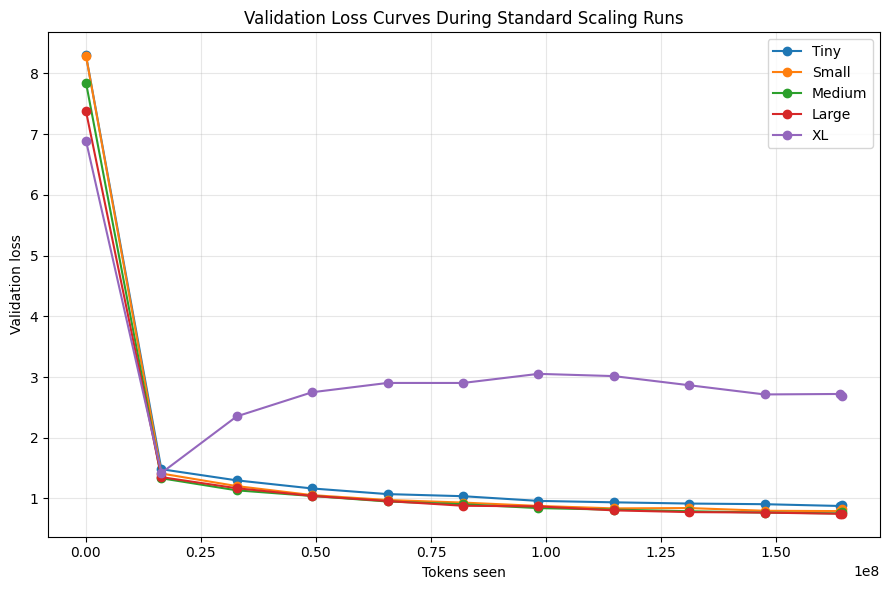

Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/plots/standard_training_curves_real.png


In [15]:

mode='sanity' if SANITY_MODE else 'real'
plt.figure(figsize=(9,6))
for cfg in MODEL_CONFIGS:
    log_path=LOGS_DIR / f'standard_scaling_{mode}_{cfg.name.lower()}.csv'
    if log_path.exists():
        df_log=pd.read_csv(log_path)
        plt.plot(df_log['tokens_seen'], df_log['val_loss'], marker='o', label=cfg.name)
    else:
        print('Missing log:', log_path)
plt.xlabel('Tokens seen')
plt.ylabel('Validation loss')
plt.title('Validation Loss Curves During Standard Scaling Runs')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
path=PLOTS_DIR / f'standard_training_curves_{mode}.png'
plt.savefig(path,dpi=200); plt.show()
print('Saved:', path)



## 13. Fitting the Scaling Law

We fit:

$$L = aN^{-lpha} + c$$

where `L` is validation loss and `N` is parameter count.


In [16]:

def scaling_law(N, a, alpha, c):
    return a * (N ** (-alpha)) + c

def fit_scaling_law(df, loss_col='final_val_loss'):
    x=df['params'].astype(float).values
    y=df[loss_col].astype(float).values
    p0=[max(y)-min(y), 0.05, min(y)*0.9]
    bounds=([0.0,0.0,0.0],[1000.0,5.0,max(y)])
    popt, pcov=curve_fit(scaling_law, x, y, p0=p0, bounds=bounds, maxfev=10000)
    pred=scaling_law(x,*popt)
    ss_res=float(np.sum((y-pred)**2)); ss_tot=float(np.sum((y-np.mean(y))**2))
    r2=1-ss_res/ss_tot if ss_tot>0 else float('nan')
    return {'a':float(popt[0]),'alpha':float(popt[1]),'c':float(popt[2]),'r2':float(r2),'covariance':pcov.tolist(),'x':x.tolist(),'y':y.tolist(),'y_pred':pred.tolist()}

mode='sanity' if SANITY_MODE else 'real'
fit_result=fit_scaling_law(df_scaling)
with open(RESULTS_DIR / f'standard_scaling_law_fit_{mode}.json','w') as f:
    json.dump(fit_result,f,indent=2)
print({k:v for k,v in fit_result.items() if k not in ['x','y','y_pred','covariance']})


{'a': 2.2393843305811711e-13, 'alpha': 5.628829028103905e-08, 'c': 1.1876963405726477, 'r2': -2.220446049250313e-16}



## 14. Plotting the Scaling Curve


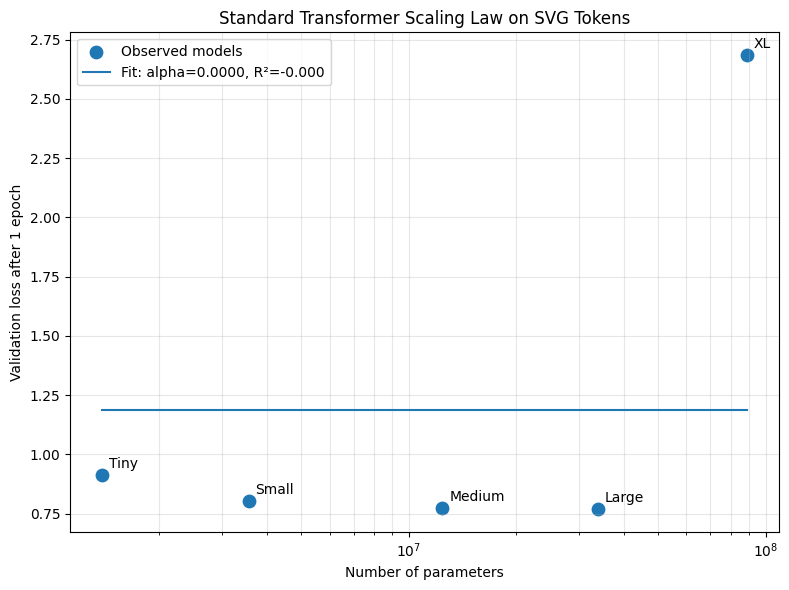

Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/plots/standard_scaling_law_real.png


In [17]:

x=np.array(fit_result['x']); y=np.array(fit_result['y'])
x_fit=np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_fit=scaling_law(x_fit, fit_result['a'], fit_result['alpha'], fit_result['c'])
plt.figure(figsize=(8,6))
plt.scatter(x,y,s=80,label='Observed models')
for _, row in df_scaling.iterrows():
    plt.annotate(row['model_name'], (row['params'], row['final_val_loss']), textcoords='offset points', xytext=(5,5))
plt.plot(x_fit,y_fit,label=f"Fit: alpha={fit_result['alpha']:.4f}, R²={fit_result['r2']:.3f}")
plt.xscale('log')
plt.xlabel('Number of parameters')
plt.ylabel('Validation loss after 1 epoch')
plt.title('Standard Transformer Scaling Law on SVG Tokens')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout()
path=PLOTS_DIR / f'standard_scaling_law_{mode}.png'
plt.savefig(path,dpi=200); plt.show()
print('Saved:', path)



## 15. Creating the Final Part 2 Report Table


In [18]:

cols=['model_name','params','final_train_loss','final_val_loss','best_val_loss','total_elapsed_sec','tokens_per_sec','gpu_memory_gb','max_steps','tokens_seen','block_size','micro_batch_size','grad_accum_steps']
df_report=df_scaling[cols].copy()
df_report['params_millions']=df_report['params']/1e6
df_report['wall_clock_hours']=df_report['total_elapsed_sec']/3600
df_report=df_report[['model_name','params','params_millions','final_train_loss','final_val_loss','best_val_loss','wall_clock_hours','tokens_per_sec','gpu_memory_gb','max_steps','tokens_seen','block_size','micro_batch_size','grad_accum_steps']]
display(df_report)
path=RESULTS_DIR / f'standard_scaling_report_table_{mode}.csv'
df_report.to_csv(path,index=False)
print('Saved:', path)


,model_name,params,params_millions,final_train_loss,final_val_loss,best_val_loss,wall_clock_hours,tokens_per_sec,gpu_memory_gb,max_steps,tokens_seen,block_size,micro_batch_size,grad_accum_steps
0,Tiny,1383168,1.383168,0.890887,0.911614,0.876584,0.060543,754118.408678,0.562698,5016,164364288,512,16,4
1,Small,3554304,3.554304,0.786774,0.801394,0.792083,0.085018,537023.168015,0.779127,5016,164364288,512,16,4
2,Medium,12417024,12.417024,0.738939,0.773271,0.754734,0.085649,533068.097540,1.262346,5016,164364288,512,16,4
3,Large,33884160,33.884160,0.740568,0.767520,0.747741,0.136754,333859.632520,2.407393,5016,164364288,512,16,4
4,XL,88594944,88.594944,2.639022,2.684681,1.420349,0.232868,196062.971891,4.479008,5016,164364288,512,16,4


Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/results/standard_scaling_report_table_real.csv



## 16. Completing the Part 2 Checklist

After the real run with `SANITY_MODE = False`, These files exist:

```text
notebook2_standard_scaling/results/lr_sweep_tiny_standard_real.csv
notebook2_standard_scaling/results/best_lr_standard_real.json
notebook2_standard_scaling/results/standard_scaling_results_real.csv
notebook2_standard_scaling/results/standard_scaling_law_fit_real.json
notebook2_standard_scaling/results/standard_scaling_report_table_real.csv
notebook2_standard_scaling/plots/lr_sweep_tiny_standard_real.png
notebook2_standard_scaling/plots/standard_training_curves_real.png
notebook2_standard_scaling/plots/standard_scaling_law_real.png
```


In [19]:
print("Author: Naman Singh")

Author: Naman Singh
